# Milestone-02: Temporal Trend Analysis
## Visualizing U.S. Disaster Declarations

Objective

This milestone focuses on analyzing how disaster declarations change over time.
The analysis includes:

- Yearly temporal trends

- Comparison of disaster types across years

- Monthly seasonality patterns

- Interpretation of long-term changes

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("../documents/database.csv")
df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


## Step 1: Time Data Validation

Before conducting temporal analysis, it is necessary to validate the date column. Incorrect or missing date values can distort trend analysis and lead to misleading conclusions.

After converting the **"Declaration Date"** column to datetime format, year and month features were extracted for aggregation purposes. No critical missing date values were found, ensuring the dataset is suitable for time-based analysis.

In [4]:
import pandas as pd

# Remove extra spaces from column names (VERY IMPORTANT)
df.columns = df.columns.str.strip()

# Convert Declaration Date to datetime
df['Declaration Date'] = pd.to_datetime(
    df['Declaration Date'],
    errors='coerce',
    dayfirst=True   # remove this line if your format is YYYY-MM-DD
)

# Extract Year and Month
df['Year'] = df['Declaration Date'].dt.year
df['Month'] = df['Declaration Date'].dt.month

# Check missing dates
print("Missing Dates:", df['Declaration Date'].isnull().sum())

# Remove invalid dates
df = df.dropna(subset=['Declaration Date'])

# Confirm changes
df.info()

Missing Dates: 27546
<class 'pandas.DataFrame'>
Index: 18639 entries, 0 to 46146
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Declaration Number                18639 non-null  str           
 1   Declaration Type                  18639 non-null  str           
 2   Declaration Date                  18639 non-null  datetime64[us]
 3   State                             18639 non-null  str           
 4   County                            18567 non-null  str           
 5   Disaster Type                     18639 non-null  str           
 6   Disaster Title                    18639 non-null  str           
 7   Start Date                        18639 non-null  str           
 8   End Date                          18508 non-null  str           
 9   Close Date                        13949 non-null  str           
 10  Individual Assistance Program     18639 n

## Step 2: Yearly Trend Analysis

This section evaluates how the total number of disaster declarations varies across years.

### Interpretation

1. The graph shows the total number of disaster declarations per year.  
2. There is a noticeable upward trend, particularly after the 1970s and more prominently after the 1990s.  
3. Sudden spikes in certain years may correspond to major natural events or policy-related changes in disaster reporting.  

Overall, the data indicates a long-term increase in disaster declarations.

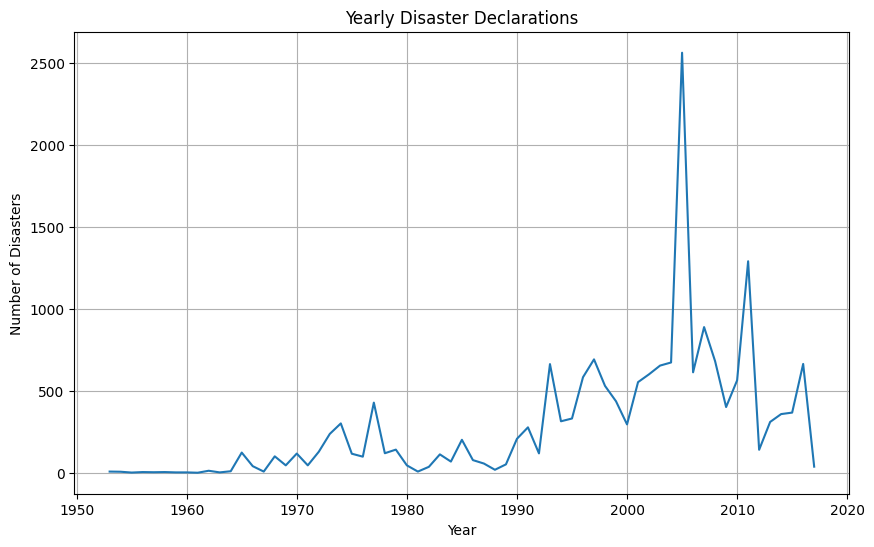

In [5]:
import matplotlib.pyplot as plt

# Group by Year
yearly_counts = df.groupby('Year').size()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_counts.index, yearly_counts.values)

plt.title("Yearly Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.grid(True)

plt.show()

## Step 3: Smoothed Trend Analysis (Rolling Average)

To better understand long-term patterns, a 5-year moving average is applied to smooth short-term fluctuations in yearly disaster counts.

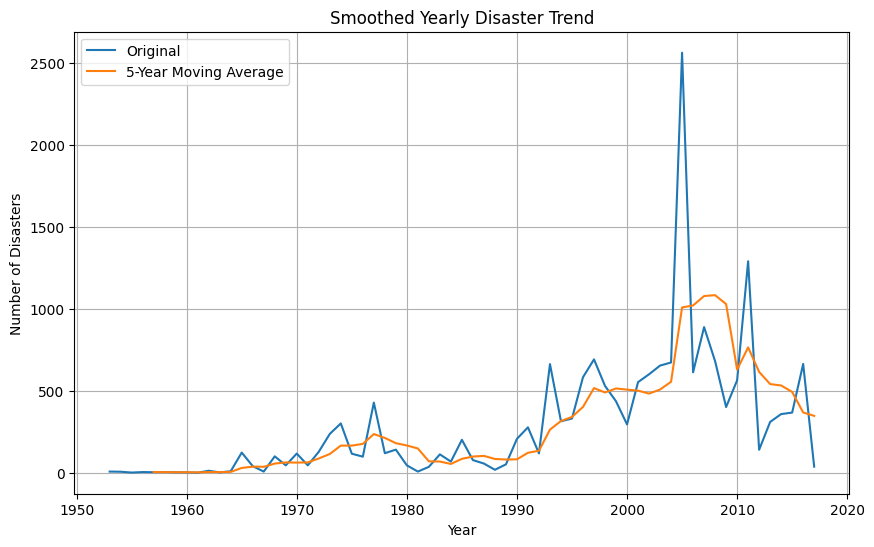

In [6]:
rolling_avg = yearly_counts.rolling(window=5).mean()

plt.figure(figsize=(10,6))
plt.plot(yearly_counts.index, yearly_counts.values, label="Original")
plt.plot(rolling_avg.index, rolling_avg.values, label="5-Year Moving Average")
plt.title("Smoothed Yearly Disaster Trend")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

1. The rolling average smooths short-term fluctuations in yearly disaster counts.  
2. It highlights the long-term increasing trend more clearly.  
3. The smoothed curve confirms gradual structural growth in disaster declarations over time.  

This analysis strengthens the conclusion that the rise in disasters is persistent rather than random.

## Step 4: Incident Type Trends Over Time

This section compares the top five most frequent disaster types across years to understand which categories dominate and how they evolve over time.

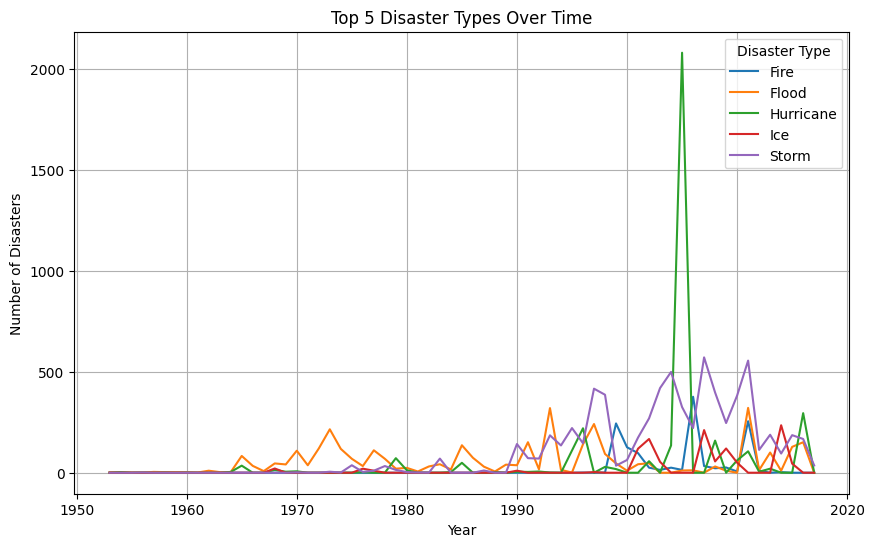

In [7]:
# Get Top 5 Disaster Types
top_types = df['Disaster Type'].value_counts().head(5).index

# Filter only top 5
df_top = df[df['Disaster Type'].isin(top_types)]

# Group by Year and Disaster Type
incident_trend_top = (
    df_top
    .groupby(['Year', 'Disaster Type'])
    .size()
    .unstack(fill_value=0)
)

# Plot
incident_trend_top.plot(figsize=(10,6))

plt.title("Top 5 Disaster Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend(title="Disaster Type")
plt.grid(True)

plt.show()

### Interpretation

1. The graph compares the yearly frequency of the top five disaster types.  
2. Storm and hurricane-related disasters appear more frequently compared to other categories.  
3. Certain disaster types show noticeable spikes in specific years, possibly due to major natural events.  

The analysis indicates that disaster frequency varies by type, with some categories contributing more significantly to the overall increase in declarations.

## Step 5: Seasonality Analysis (Monthly Trends)

This section examines whether disaster declarations follow seasonal patterns by analyzing their distribution across months.

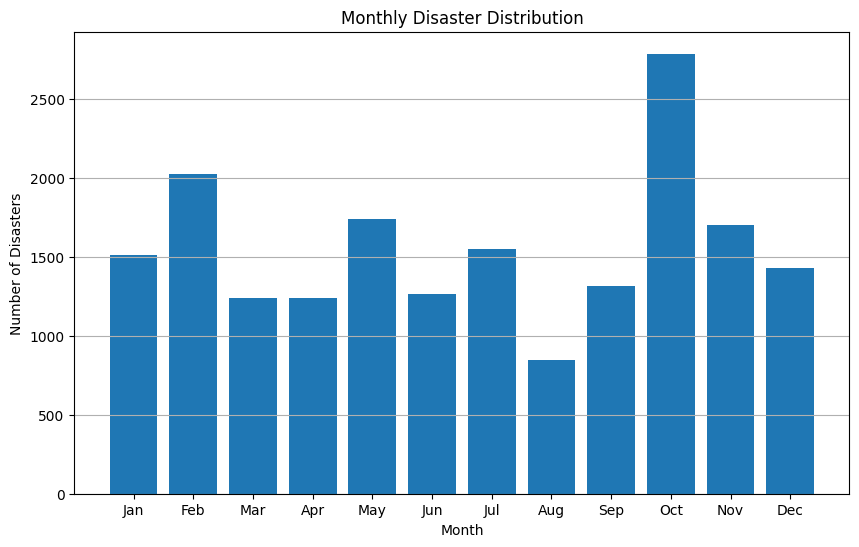

In [8]:
import matplotlib.pyplot as plt

# Group by Month (capital M)
monthly_counts = df.groupby('Month').size()

# Sort months properly (1 to 12)
monthly_counts = monthly_counts.sort_index()

months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(10,6))
plt.bar(months, monthly_counts.values)

plt.title("Monthly Disaster Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")
plt.grid(axis='y')

plt.show()

### Interpretation

1. The graph shows the number of disaster declarations distributed across different months.  
2. Certain months, especially late summer and early autumn, display higher disaster frequencies.  
3. Some early-year months also show moderate activity, possibly due to winter-related disasters.  

The results indicate that disaster occurrences follow seasonal patterns rather than being evenly distributed throughout the year.

## Step 6: Cumulative Disaster Growth Analysis

This section analyzes the cumulative number of disaster declarations over time to understand long-term acceleration in disaster frequency.

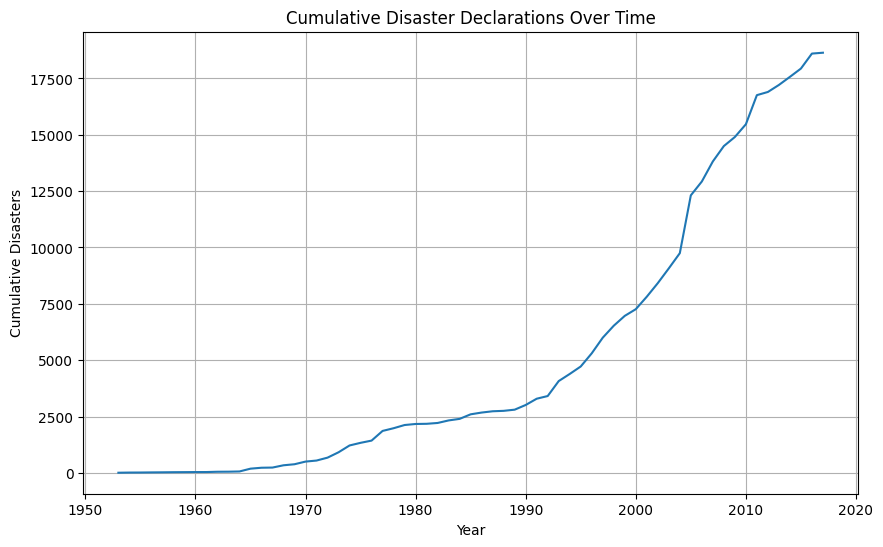

In [9]:
import matplotlib.pyplot as plt

# Create yearly counts (if not already created)
yearly_counts = df.groupby('Year').size().sort_index()

# Cumulative sum
cumulative = yearly_counts.cumsum()

# Plot
plt.figure(figsize=(10,6))
plt.plot(cumulative.index, cumulative.values)

plt.title("Cumulative Disaster Declarations Over Time")
plt.xlabel("Year")
plt.ylabel("Cumulative Disasters")
plt.grid(True)

plt.show()

### Interpretation

1. The cumulative graph shows the total number of disaster declarations accumulating over time.  
2. The curve becomes steeper in recent decades, indicating a higher frequency of disasters compared to earlier years.  
3. The accelerating slope suggests that disaster declarations are increasing at a sustained rate.  

This analysis reinforces the conclusion that disaster occurrence has grown structurally over time rather than remaining constant.

## Peak Year Identification

This section identifies the year with the highest number of disaster declarations and the corresponding maximum value.

In [10]:
# Create yearly counts (if not already created)
yearly_counts = df.groupby('Year').size().sort_index()

# Find peak year
peak_year = yearly_counts.idxmax()
peak_value = yearly_counts.max()

print("Peak Year:", peak_year)
print("Maximum Number of Disasters:", peak_value)

Peak Year: 2005.0
Maximum Number of Disasters: 2565


### Interpretation

1. The peak year represents the year with the highest recorded number of disaster declarations.  
2. The unusually high value in this year may be associated with significant natural events or multiple large-scale disasters.  
3. Identifying the peak year helps highlight extreme periods in disaster history.  

This analysis provides insight into the most critical year within the observed timeframe.

## Milestone-03: Geographical Distribution Analysis

## Visualizing U.S. Disaster Declarations by State

## Objective

This milestone focuses on analyzing the geographical distribution of disaster declarations across the United States.

The analysis includes:

State-wise disaster frequency

Identification of disaster hotspots

Comparison of disaster counts across states

Understanding dominant disaster types in each region

## Step 1: Geographic Aggregation

## 1.1 State-Level Aggregation
 
 This step groups the dataset by state and counts the total number of disaster declarations for each state.
The results help identify which states experience the highest number of disasters

In [11]:
state_counts = df.groupby('State').size().reset_index(name='Disaster Count')

state_counts.sort_values(by='Disaster Count', ascending=False).head(10)

,State,Disaster Count
50,TX,1789
20,KY,1164
28,MO,1162
41,OK,1022
19,KS,741
18,IN,726
12,GA,669
52,VA,634
49,TN,621
32,NC,564


## Interpretation

1.The table shows the number of disaster declarations recorded for each state.

2.States with higher counts indicate regions that experience disasters more frequently.

3.These states may be more vulnerable to natural hazards such as hurricanes, floods, or wildfires.

This aggregation provides the foundation for identifying geographic disaster hotspots

## 1..2 State + Incident Type Aggregation

To better understand disaster patterns, the dataset is grouped by state and disaster type.
This allows us to identify which types of disasters occur most frequently in each state.

In [12]:
state_incident_counts = df.groupby(['State','Disaster Type']).size().reset_index(name='Count')

state_incident_counts.head(10)

,State,Disaster Type,Count
0,AK,Earthquake,6
1,AK,Fire,10
2,AK,Flood,18
3,AK,Other,1
4,AK,Storm,12
5,AK,Winter,12
6,AL,Flood,22
7,AL,Hurricane,159
8,AL,Storm,164
9,AL,Tornado,24


## Interpretation

1.The table displays the number of occurrences for each disaster type within each state.

2.Some states may show higher counts for specific disaster types such as hurricanes, floods, or fires.

3.This analysis helps identify dominant disasters in different regions of the country.

Understanding these patterns is useful for disaster preparedness and regional risk assessment.

## Identify Top Disaster Types by State

This step highlights which disaster types dominate in the most affected states.

In [13]:
top_states = state_counts.sort_values(by='Disaster Count', ascending=False).head(10)['State']

state_disaster_summary = state_incident_counts[state_incident_counts['State'].isin(top_states)]

state_disaster_summary.head()

,State,Disaster Type,Count
56,GA,Fire,2
57,GA,Flood,11
58,GA,Hurricane,260
59,GA,Ice,136
60,GA,Storm,135


## Interpretation

1.This analysis focuses on the most disaster-prone states.

2.It shows how different disaster types contribute to the total disaster count in those states.

3.Certain states may show strong dominance of particular disaster types.

## 2.3 Regional Comparison
States can be grouped into larger geographic regions such as West, Midwest, South, and Northeast to analyze broader spatial patterns.

In [14]:
region_map = {
    'CA':'West','WA':'West','OR':'West','NV':'West','AZ':'West','UT':'West','CO':'West','ID':'West','MT':'West','WY':'West',
    'TX':'South','FL':'South','GA':'South','LA':'South','AL':'South','MS':'South','SC':'South','NC':'South','TN':'South','KY':'South',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest','MN':'Midwest','IA':'Midwest','MO':'Midwest',
    'NY':'Northeast','PA':'Northeast','NJ':'Northeast','MA':'Northeast','CT':'Northeast','RI':'Northeast','NH':'Northeast','VT':'Northeast','ME':'Northeast'
}

df['Region'] = df['State'].map(region_map)

region_counts = df.groupby('Region').size().reset_index(name='Disaster Count')

region_counts

,Region,Disaster Count
0,Midwest,4043
1,Northeast,1363
2,South,6724
3,West,1428


## Interpretation

1.The regional aggregation summarizes disaster occurrences across major U.S. regions.

2.Some regions may experience more disasters due to geographical and climatic conditions.

3.For example, southern states often experience hurricanes and floods, while western states may face wildfires.

This comparison helps reveal large-scale geographic patterns in disaster occurrences.

## 2. Core Visualizations 

## 2.1 Choropleth Map 
A choropleth map is used to visualize disaster counts across different states in the United States.
In this map, each state is colored according to the number of disaster declarations.

States with darker colors represent higher disaster frequency, while lighter colors indicate fewer disasters.
This visualization helps easily identify disaster hotspots across the country.

In [15]:
import plotly.express as px

state_counts = df.groupby('State').size().reset_index(name='Disaster Count')

fig = px.choropleth(
    state_counts,
    locations='State',
    locationmode="USA-states",
    color='Disaster Count',
    scope="usa",
    color_continuous_scale="Reds",
    title="U.S. Disaster Declarations by State"
)

fig.show()

## Interpretation

1.The choropleth map highlights disaster frequency across U.S. states.

2.States with darker shades represent higher disaster declarations.

3.Geographic clusters of disasters can be identified, especially in regions prone to hurricanes, floods, or wildfires.

This visualization helps identify disaster hotspots and regional vulnerability patterns.

## 2.2 State Comparison Chart
This visualization compares disaster counts across the top 10 states with the highest number of disaster declarations.

A bar chart is used to clearly show the difference in disaster frequency among these states.

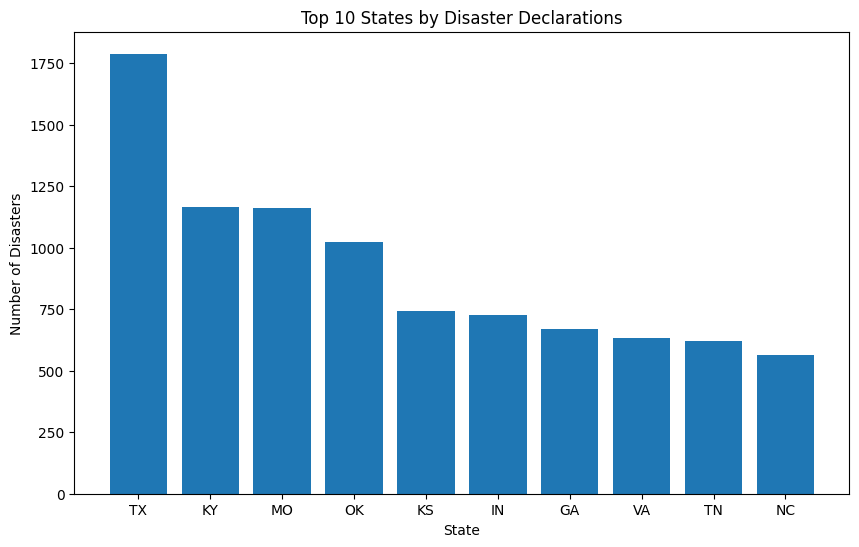

In [16]:
import matplotlib.pyplot as plt

top_states = state_counts.sort_values(by='Disaster Count', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top_states['State'], top_states['Disaster Count'])

plt.title("Top 10 States by Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.show()

## Interpretation

1.The chart displays the states with the highest number of disaster declarations.

2.These states are more frequently affected by natural hazards.

3.The visualization highlights geographic disparities in disaster occurrences.

This helps identify states that require stronger disaster preparedness and management strategies.

## 2.3 Incident Type Distribution by State
This visualization shows how different disaster types contribute to total disaster declarations within each state.

A stacked bar chart is used to compare the composition of disasters across states.

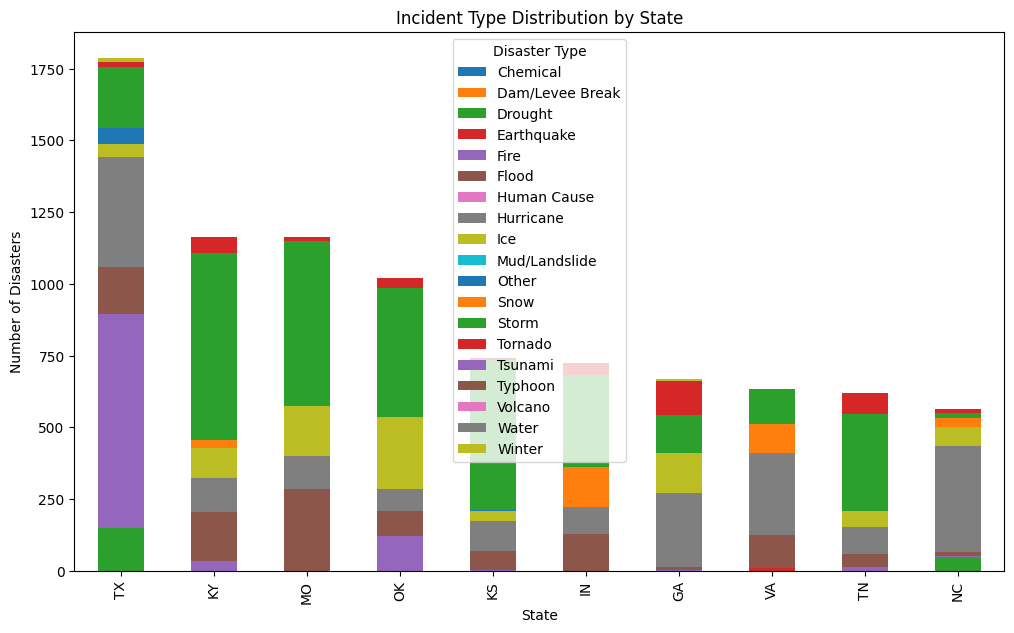

In [17]:
incident_state = df.groupby(['State','Disaster Type']).size().unstack(fill_value=0)

top_states = incident_state.sum(axis=1).sort_values(ascending=False).head(10)

incident_state.loc[top_states.index].plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

plt.title("Incident Type Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.legend(title="Disaster Type")
plt.show()

## Interpretation

1.Each bar represents a state, and each colored segment represents a disaster type.

2.The chart shows how different disasters contribute to total declarations in each state.

3.Some states may show dominance of specific disasters such as floods, hurricanes, or fires.

This helps understand the composition of disasters across different states.

## 2.4 Incident Type Hotspot Map
This visualization highlights hotspots for a specific disaster type, such as hurricanes, fires, or floods.

For example, the following map shows the geographic distribution of flood disasters.

In [18]:
flood_data = df[df['Disaster Type'] == 'Flood']

flood_counts = flood_data.groupby('State').size().reset_index(name='Flood Count')

fig = px.choropleth(
    flood_counts,
    locations='State',
    locationmode="USA-states",
    color='Flood Count',
    scope="usa",
    color_continuous_scale="Blues",
    title="Flood Disaster Hotspots in the U.S."
)

fig.show()

## Interpretation

1.The map highlights states where floods occur most frequently.

2.Darker states indicate regions with higher flood-related disasters.

3.Such maps help identify hazard-specific hotspots across the country.

This visualization can also be created for hurricanes, fires, and storms to understand disaster patterns for specific hazards.